# 1. Pal Distribution and Characteristics:

## 1.1 Count of Pals by Type
See which Pal types are most common

In [1]:
import pandas as pd
import plotly.express as px
import dash
from dash import dcc, html

# Load dataset
file_path = "Pals.csv"
df = pd.read_csv(file_path)

# Function to count occurrences of each Pal Type
def count_pal_types_plotly(df):
    type_counts = {}
    for types in df['Type']:
        if isinstance(types, str):
            for t in types.split(','):
                t = t.strip()  
                type_counts[t] = type_counts.get(t, 0) + 1
        else:
            type_counts[types] = type_counts.get(types, 0) + 1  

    type_counts_df = pd.DataFrame(list(type_counts.items()), columns=['Type', 'Count'])
    return type_counts_df

# Prepare data for Dash
type_counts_plotly_df = count_pal_types_plotly(df)

# Initialize Dash app
app = dash.Dash(__name__)

app.layout = html.Div([
    html.H1("Interactive Pal Type Count Visualization", style={'text-align': 'center'}),
    
    # Bar Chart
    dcc.Graph(
        id='bar-chart',
        figure=px.bar(
            type_counts_plotly_df, 
            x='Type', 
            y='Count', 
            title='Count of Pals by Type',
            labels={'Type': 'Pal Type', 'Count': 'Count'},
            template='plotly_white',
            color='Type'
        ).update_layout(
            xaxis_tickangle=-45,
            height=500,
            width=800
        )
    )
])

if __name__ == '__main__':
    app.run(port = 8071)

## 1.2 Count of Pals by Rarity
Understand the distribution of Pal rarity.

In [2]:
import pandas as pd
import plotly.express as px
import dash
from dash import dcc, html

# Load dataset
file_path = "Pals.csv"
df = pd.read_csv(file_path)

# Get rarity counts
rarity_counts_df = df['Rarity'].value_counts().reset_index()
rarity_counts_df.columns = ['Rarity', 'Count']

# Sort rarity levels
rarity_counts_df = rarity_counts_df.sort_values(by='Rarity')

# Initialize Dash app
app = dash.Dash(__name__)

app.layout = html.Div([
    html.H1("Interactive Pal Rarity Count Visualization", style={'text-align': 'center'}),
    
    # Bar Chart
    dcc.Graph(
        id='bar-chart',
        figure=px.bar(
            rarity_counts_df, 
            x='Rarity', 
            y='Count', 
            title='Count of Pals by Rarity (Sorted)',
            labels={'Rarity': 'Rarity Level', 'Count': 'Pal Count'},
            template='plotly_white',
            color='Rarity'
        ).update_layout(
            xaxis_tickangle=-45,
            height=500,
            width=800
        )
    )
])

if __name__ == '__main__':
    app.run(port = 8055)



## 1.3 Average Stats by Type
: Compare the average HP, Attack, Defense, etc., 

In [3]:
import pandas as pd
import plotly.express as px
import dash
from dash import dcc, html

# Load dataset
file_path = "Pals.csv"
df = pd.read_csv(file_path)

# Define combat stats columns
stats_columns = ['HP', 'Melee Attack', 'Magic Attack', 'Defense']

# Group by 'Type' and calculate the mean for the stats columns
average_stats_by_type = df.groupby('Type')[stats_columns].mean().reset_index()

# Convert DataFrame to long format for Plotly
melted_stats = average_stats_by_type.melt(id_vars='Type', value_vars=stats_columns, var_name='Stat', value_name='Average Value')

# Initialize Dash app
app = dash.Dash(__name__)

app.layout = html.Div([
    html.H1("Interactive Average Stats by Pal Type", style={'text-align': 'center'}),
    
    # Bar Chart
    dcc.Graph(
        id='bar-chart',
        figure=px.bar(
            melted_stats, 
            x='Type', 
            y='Average Value', 
            color='Stat', 
            title='Average Combat Stats by Pal Type',
            barmode='group',
            labels={'Type': 'Pal Type', 'Average Value': 'Average Stat Value', 'Stat': 'Stat'},
            template='plotly_white'
        ).update_layout(
            xaxis_tickangle=-45,
            height=600,
            width=800
        )
    )
])

if __name__ == '__main__':
    app.run(port = 8056)

## 1.4	Average Price by Rarity: 
    See if there's a correlation between rarity and price.

In [4]:
import pandas as pd
import plotly.express as px
import dash
from dash import dcc, html

# Load dataset
file_path = "Pals.csv"
df = pd.read_csv(file_path)

# Initialize Dash app
app = dash.Dash(__name__)

app.layout = html.Div([
    html.H1("Interactive Scatter Plot: Price vs. Rarity", style={'text-align': 'center'}),
    
    # Scatter Plot
    dcc.Graph(
        id='scatter-plot',
        figure=px.scatter(
            df, 
            x="Rarity", 
            y="Price", 
            title="Scatter Plot of Price vs. Rarity",
            labels={"Rarity": "Rarity Level", "Price": "Pal Price"},
            template="plotly_white"  # Ensure clean theme
        ).update_layout(
            height=500,
            width=800
        )
    )
])

if __name__ == '__main__':
    app.run(port = 8057)

## 1.5  Distribution of Numerical Stats: Examine the distribution of HP, Attack, Defense, 

In [5]:
import pandas as pd
import plotly.graph_objects as go
import dash
from dash import dcc, html

# Load dataset
file_path = "Pals.csv"
df = pd.read_csv(file_path)

# Define attributes & colors
attributes = ["Melee Attack", "Magic Attack", "HP", "Defense"]
colors = ["blue", "green", "red", "purple"]

# Initialize Dash app
app = dash.Dash(__name__)

app.layout = html.Div([
    html.H1("Interactive Distribution of Combat Stats", style={'text-align': 'center'}),
    
    # Histogram Graph
    dcc.Graph(
        id='histogram-plot',
        figure=go.Figure([
            go.Histogram(x=df[attr], name=attr, opacity=0.6, marker_color=color)
            for attr, color in zip(attributes, colors)
        ]).update_layout(
            title="Distribution of Attack, Magic Attack, HP, and Defense",
            xaxis_title="Value",
            yaxis_title="Count",
            barmode="overlay",
            template="plotly_white"
        )
    )
])

if __name__ == '__main__':
    app.run(port = 8058)

## 1.6 Comparing Stat Distributions by Type or Rarity

In [6]:
import pandas as pd
import plotly.express as px
import dash
from dash import dcc, html
from dash.dependencies import Input, Output

# Load dataset
file_path = "Pals.csv"
df = pd.read_csv(file_path)

# Define key stats for comparison
stats = ["HP", "Melee Attack", "Magic Attack", "Defense"]

# Initialize Dash app
app = dash.Dash(__name__)

app.layout = html.Div([
    html.H1("Interactive Box Plot - Stat Distributions", style={'text-align': 'center'}),
    
    # Dropdown to switch between Type and Rarity
    html.Label("Select Grouping:"),
    dcc.Dropdown(
        id="group-dropdown",
        options=[
            {"label": "Pal Type", "value": "Type"},
            {"label": "Rarity", "value": "Rarity"}
        ],
        value="Type",
        style={'width': '50%'}
    ),

    # Box Plot
    dcc.Graph(id="box-plot")
])

@app.callback(
    Output("box-plot", "figure"),
    [Input("group-dropdown", "value")]
)
def update_box_plot(selected_group):
    fig = px.box(
        df, x=selected_group, y=stats,
        title=f"Stat Distributions by {selected_group}",
        labels={"value": "Stat Value"},
        template="plotly_white"
    )
    return fig

if __name__ == "__main__":
    app.run(port = 8058)

# Pal Skills and Work Suitability:

## 2.1 Stacked Bar Chart Number of Pals with Different Skill Combinations

In [7]:
import pandas as pd
import plotly.express as px
import dash
from dash import dcc, html

# Load dataset
file_path = "Pals.csv"
df = pd.read_csv(file_path)

# Define skill columns
skills = [
    "Kindling", "Planting", "Handiwork", "Lumbering", "Medicine Production",
    "Transportation", "Watering", "Generating Electricity", "Gathering", "Mining",
    "Cooling", "Farming"
]

# Fix column names in the CSV file if necessary
df.columns = df.columns.str.strip()

# Convert missing values to 0
df[skills] = df[skills].fillna(0)

# Group by Pal Type and sum skill levels
skill_distribution = df.groupby("Type")[skills].sum().reset_index()

# Convert data to long format for stacked visualization
df_long = skill_distribution.melt(id_vars=["Type"], var_name="Skill", value_name="Total Level")

# Initialize Dash app
app = dash.Dash(__name__)

app.layout = html.Div([
    html.H1("Stacked Bar Chart of Skill Levels by Pal Type", style={'text-align': 'center'}),
    
    # Bar Chart
    dcc.Graph(
        id='stacked-bar-chart',
        figure=px.bar(
            df_long, 
            x="Type", 
            y="Total Level", 
            color="Skill", 
            title="Stacked Bar Chart of Skill Levels by Pal Type",
            labels={"Total Level": "Skill Level"},
            template="plotly_white",
            barmode="stack"
        ).update_layout(
            xaxis_tickangle=-45,
            height=600,
            width=900
        )
    )
])

if __name__ == '__main__':
    app.run(port = 8060)

## 2.2	Number of Pals with Different Skill Combinations

In [8]:
import pandas as pd
import plotly.express as px
import dash
from dash import dcc, html

# Load dataset
file_path = "Pals.csv"
df = pd.read_csv(file_path)

# Process 'Work' column: Split multiple skills & count occurrences
df["Work Skills"] = df["Work"].str.split(", ")
skills_counts = df.explode("Work Skills")["Work Skills"].value_counts().reset_index()
skills_counts.columns = ["Skill", "Count"]

# Initialize Dash app
app = dash.Dash(__name__)

app.layout = html.Div([
    html.H1("Interactive Stacked Bar Chart - Work Skill Distribution", style={'text-align': 'center'}),

    # Bar Chart
    dcc.Graph(
        id="stacked-bar-chart",
        figure=px.bar(
            skills_counts, 
            x="Skill", 
            y="Count", 
            title="Number of Pals with Different Skill Combinations",
            labels={"Skill": "Work Skill", "Count": "Number of Pals"},
            template="plotly_white",
            color="Skill"
        ).update_layout(
            xaxis_tickangle=-45,
            height=600,
            width=800
        )
    )
])

if __name__ == "__main__":
    app.run(port=8061)

## 2.3 Skill Correlation Heatmap
Goal: Identify relationships between different skill levels—do some tend to increase together?


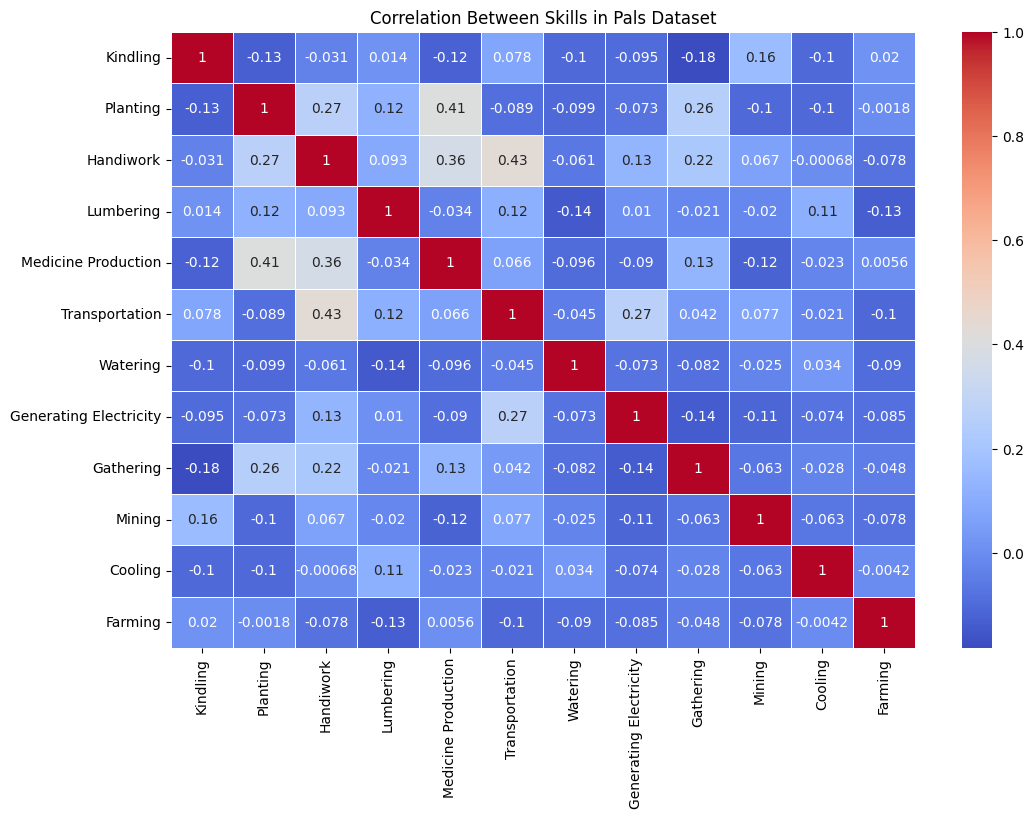

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
file_path = "Pals.csv"
df = pd.read_csv(file_path)

# Define skill columns (fixing the typo by separating "Gathering" and "Mining")
skills = [
    "Kindling", "Planting", "Handiwork", "Lumbering", "Medicine Production",
    "Transportation", "Watering", "Generating Electricity", "Gathering", "Mining",
    "Cooling", "Farming"
]

# Convert missing values to 0 and ensure numeric format
df[skills] = df[skills].fillna(0).astype(float)

# Compute correlation matrix
corr_matrix = df[skills].corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Between Skills in Pals Dataset")
plt.show()

## 2.4 Pal Skills Matrix Heatmap
Goal: See which Pals excel in specific skills at a glance


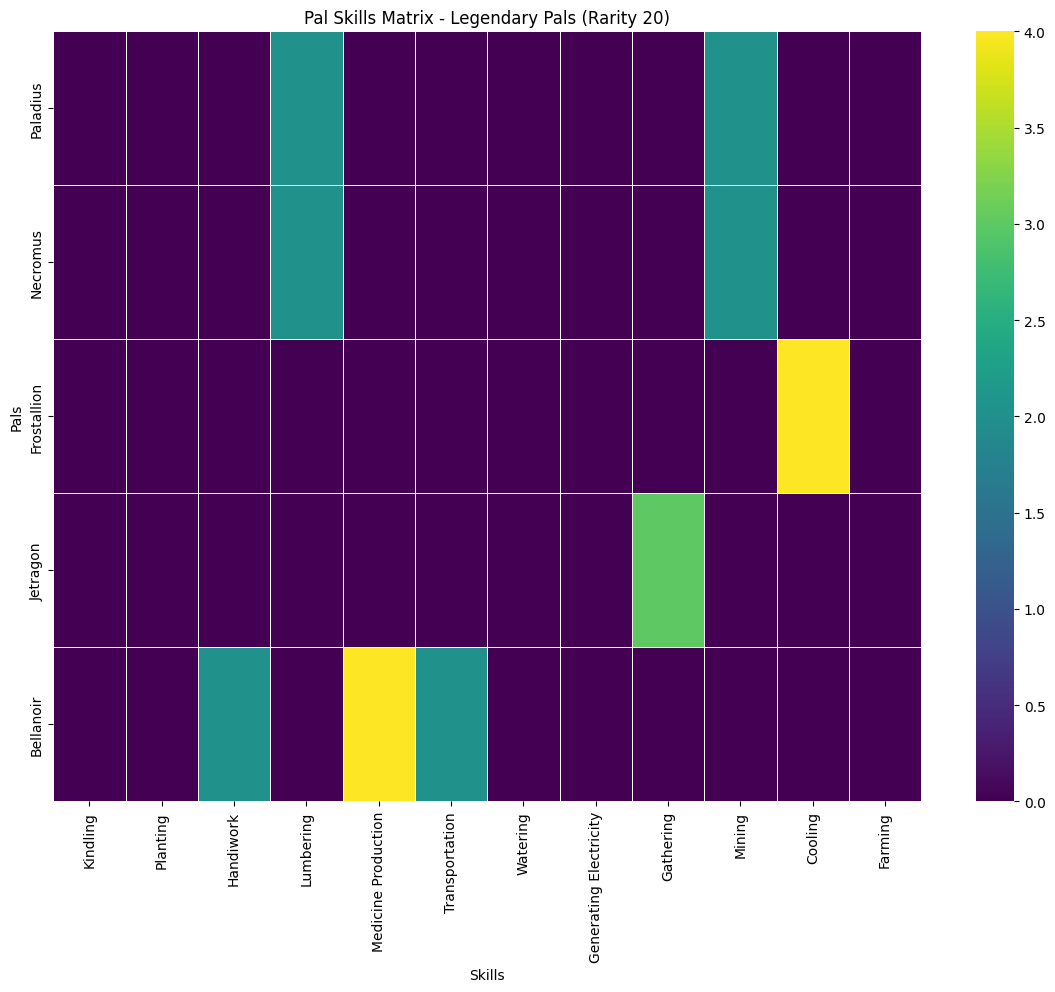

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
file_path = "Pals.csv"
df = pd.read_csv(file_path)

# Correct the skills list
skills = [
    "Kindling", "Planting", "Handiwork", "Lumbering", "Medicine Production",
    "Transportation", "Watering", "Generating Electricity", "Gathering", "Mining",
    "Cooling", "Farming"
]

# Check if all skills exist in the dataset
missing_columns = [skill for skill in skills if skill not in df.columns]
if missing_columns:
    print(f"Missing columns in the dataset: {missing_columns}")
else:
    # Filter dataset for Legendary Pals (Rarity 20)
    rarity_20_pals = df[df["Rarity"] == 20]

    # Ensure skills exist and handle missing values
    rarity_20_skills = rarity_20_pals[skills].fillna(0).astype(float)

    # Plot matrix heatmap
    plt.figure(figsize=(14, 10))
    sns.heatmap(rarity_20_skills, yticklabels=rarity_20_pals["Name"], cmap="viridis", linewidths=0.5)
    plt.title("Pal Skills Matrix - Legendary Pals (Rarity 20)")
    plt.xlabel("Skills")
    plt.ylabel("Pals")
    plt.show()


## 2.4	Parallel Coordinates Plot for Comparing Multiple Skills Simultaneously: 
Visualize how different Pals rank across multiple work skills. This can help identify well-rounded Pals or specialists.



In [11]:
import pandas as pd
import plotly.express as px
import dash
from dash import dcc, html

# Load dataset
file_path = "Pals.csv"
df = pd.read_csv(file_path)

# Define skill columns
skills = [
    "Kindling", "Planting", "Handiwork", "Lumbering", "Medicine Production",
    "Transportation", "Watering", "Generating Electricity", "Gathering", "Mining",
    "Cooling", "Farming"
]

# Convert missing values to 0 and ensure numeric format
df[skills] = df[skills].fillna(0).astype(float)

# Normalize skill levels (scaling between 0-1 for better comparison)
df_normalized = df.copy()
for skill in skills:
    df_normalized[skill] = (df[skill] - df[skill].min()) / (df[skill].max() - df[skill].min())

# Map 'Type' column to numeric values for coloring
type_mapping = {type_name: idx for idx, type_name in enumerate(df["Type"].unique())}
df_normalized["Type_Numeric"] = df["Type"].map(type_mapping)

# Initialize Dash app
app = dash.Dash(__name__)

app.layout = html.Div([
    html.H1("Parallel Coordinates Plot - Comparing Pals' Skills", style={'text-align': 'center'}),
    
    # Parallel Coordinates Plot
    dcc.Graph(
        id="parallel-coordinates",
        figure=px.parallel_coordinates(
            df_normalized,
            dimensions=skills,
            color="Type_Numeric",
            title="Parallel Coordinates Plot - Comparing Pals' Skills",
            labels={skill: skill for skill in skills},
            template="plotly_white",
            color_continuous_scale=px.colors.sequential.Viridis
        )
    )
])

if __name__ == "__main__":
    app.run(port=8063)

# 3 Pal Combat Attributes

## 3.1 3D Combat Stats Visualization

In [1]:
import pandas as pd
import plotly.graph_objects as go
import dash
from dash import dcc, html
from dash.dependencies import Input, Output

# Load dataset
file_path = "Pals.csv"
df = pd.read_csv(file_path)

# Compute average attack
df["Average Attack"] = (df["Melee Attack"] + df["Magic Attack"]) / 2

# Initialize Dash app
app = dash.Dash(__name__)

app.layout = html.Div([
    html.H1("3D Combat Stats Visualization", style={'text-align': 'center'}),
    
    # Dropdown for Pal selection
    dcc.Dropdown(
        id='pal-dropdown',
        options=[{'label': name, 'value': name} for name in df["Name"]],
        value=df["Name"][0],
        placeholder="Select a Pal",
        style={'width': '50%'}
    ),

    # 3D Scatter Plot
    dcc.Graph(id='scatter-plot')
])

@app.callback(
    Output('scatter-plot', 'figure'),
    [Input('pal-dropdown', 'value')]
)
def update_scatter_plot(selected_pal):
    pal_data = df[df["Name"] == selected_pal].iloc[0]
    
    fig = go.Figure(data=[
        go.Scatter3d(
            x=[pal_data["Average Attack"]], 
            y=[pal_data["Defense"]], 
            z=[pal_data["HP"]],
            mode='markers',
            marker=dict(size=8, color=pal_data["Average Attack"], colorscale="Viridis", opacity=0.8)
        )
    ])

    fig.update_layout(
        title=f"3D Stats Plot for {selected_pal}",
        scene=dict(
            xaxis_title="Average Attack",
            yaxis_title="Defense",
            zaxis_title="HP"
        ),
        template="plotly_white"
    )
    
    return fig

if __name__ == '__main__':
    app.run(port = 8052) 

## 3.2 Comparing Combat Stats of Individual Pals or Pal Types: Visualize the strengths and weaknesses of a Pal across different combat stats (Melee Attack, Shot Attack, Defense, Support, Enemy Receive Damage Rate).


In [13]:
import pandas as pd
import plotly.express as px
import dash
from dash import dcc, html
from dash.dependencies import Input, Output

# Load dataset
file_path = "Pals.csv"
df = pd.read_csv(file_path)

# Define combat stats
combat_stats = ["Melee Attack", "Magic Attack", "Defense", "Support", "Enemy Receive Damage Rate"]

# Initialize Dash app
app = dash.Dash(__name__)

app.layout = html.Div([
    html.H1("Pal Combat Stats Radar Chart", style={'text-align': 'center'}),
    
    # Dropdown for Pal selection
    dcc.Dropdown(
        id='pal-dropdown',
        options=[{'label': name, 'value': name} for name in df["Name"]],
        value=df["Name"][0],  # Default selection
        placeholder="Select a Pal",
        style={'width': '50%'}
    ),

    # Radar Chart
    dcc.Graph(id='radar-chart')
])

@app.callback(
    Output('radar-chart', 'figure'),
    [Input('pal-dropdown', 'value')]
)
def update_radar_chart(selected_pal):
    pal_data = df[df["Name"] == selected_pal][combat_stats].iloc[0]
    
    radar_df = pd.DataFrame({
        "Stat": combat_stats,
        "Value": pal_data.values
    })

    fig = px.line_polar(
        radar_df,
        r="Value",
        theta="Stat",
        line_close=True,
        title=f"Combat Stats Radar Chart for {selected_pal}",
        template="plotly_white"
    )
    
    return fig

if __name__ == '__main__':
    app.run(port = 8051)

## 3.3	Relationship between Speed Stats

In [14]:
import pandas as pd
import plotly.express as px
import dash
from dash import dcc, html

# Load dataset
file_path = "Pals.csv"
df = pd.read_csv(file_path)

# Initialize Dash app
app = dash.Dash(__name__)

app.layout = html.Div([
    html.H1("Interactive Scatter Plots - Pal Speeds", style={'text-align': 'center'}),

    # Scatter Plot: Slow Walk Speed vs. Run Speed
    dcc.Graph(
        id="scatter-walk-run",
        figure=px.scatter(
            df, 
            x="Slow Walk Speed", 
            y="Run Speed", 
            color="Type", 
            hover_data=["Name", "Rarity"],
            title="Relationship Between Slow Walk Speed and Run Speed",
            labels={"Slow Walk Speed": "Walk Speed", "Run Speed": "Run Speed"},
            template="plotly_white"
        )
    ),

    # Scatter Plot: Run Speed vs. Ride Sprint Speed
    dcc.Graph(
        id="scatter-run-sprint",
        figure=px.scatter(
            df, 
            x="Run Speed", 
            y="Ride Sprint Speed", 
            color="Rarity", 
            hover_data=["Name", "Type"],
            title="Relationship Between Run Speed and Ride Sprint Speed",
            labels={"Run Speed": "Run Speed", "Ride Sprint Speed": "Sprint Speed"},
            template="plotly_white"
        )
    )
])

if __name__ == "__main__":
    app.run(port=8064)

## 3.4 Pal Combat % 

In [15]:
import pandas as pd
import plotly.express as px
import dash
from dash import dcc, html
from dash.dependencies import Input, Output

# Load the CSV file
file_path = "Pals.csv"  # Update if needed
df = pd.read_csv(file_path)

# Initialize the Dash app
app = dash.Dash(__name__)

app.layout = html.Div([
    html.H1("Pal Stats Visualization"),
    
    # Dropdown for selecting a Pal
    dcc.Dropdown(
        id='pal-dropdown',
        options=[{'label': name, 'value': name} for name in df["Name"]],
        value=df["Name"][0],
        placeholder="Select a Pal",
        style={'width': '50%'}
    ),

    # Pie chart
    dcc.Graph(id='pie-chart')
])

@app.callback(
    Output('pie-chart', 'figure'),
    [Input('pal-dropdown', 'value')]
)
def update_pie_chart(selected_pal):
    pal_data = df[df["Name"] == selected_pal].iloc[0]
    stats = {
        "Melee Attack": pal_data["Melee Attack"],
        "Magic Attack": pal_data["Magic Attack"],
        "HP": pal_data["HP"],
        "Defense": pal_data["Defense"]
    }

    fig = px.pie(
        values=list(stats.values()),
        names=list(stats.keys()),
        title=f"Stats Breakdown for {selected_pal}",
        template="plotly_white"
    )
    
    return fig

if __name__ == '__main__':
    app.run(port = 8050)

## 3.5 Relationship between Attack and Defense: See if there's a correlation between a Pal's attack power and its defensive capabilities. Color-code by Type or Rarity.


In [16]:
import pandas as pd
import plotly.express as px
import dash
from dash import dcc, html
from dash.dependencies import Input, Output

# Load dataset
file_path = "Pals.csv"
df = pd.read_csv(file_path)

# Initialize Dash app
app = dash.Dash(__name__)

app.layout = html.Div([
    html.H1("Interactive Scatter Plot - Melee Attack vs. Defense", style={'text-align': 'center'}),

    # Dropdown to choose color categorization
    html.Label("Color By:"),
    dcc.Dropdown(
        id="color-dropdown",
        options=[
            {"label": "Pal Type", "value": "Type"},
            {"label": "Rarity", "value": "Rarity"}
        ],
        value="Type",
        style={'width': '50%'}
    ),

    # Scatter Plot
    dcc.Graph(id="scatter-plot")
])

@app.callback(
    Output("scatter-plot", "figure"),
    [Input("color-dropdown", "value")]
)
def update_scatter_plot(selected_color):
    fig = px.scatter(
        df, 
        x="Melee Attack", 
        y="Defense", 
        color=selected_color, 
        hover_data=["Name", "Rarity"] if selected_color == "Type" else ["Name", "Type"],
        title=f"Relationship Between Melee Attack and Defense (Color-coded by {selected_color})",
        labels={"Melee Attack": "Attack Power", "Defense": "Defense Strength"},
        template="plotly_white"
    )
    return fig

if __name__ == "__main__":
    app.run(port=8065)

# Pal Value and Economy

## Price Distribution by Rarity

In [17]:
import pandas as pd
import plotly.express as px
import dash
from dash import dcc, html

# Load dataset
file_path = "Pals.csv"
df = pd.read_csv(file_path)

# Initialize Dash app
app = dash.Dash(__name__)

app.layout = html.Div([
    html.H1("Violin Plot - Price Distribution by Rarity", style={'text-align': 'center'}),

    # Violin Plot
    dcc.Graph(
        id="violin-plot",
        figure=px.violin(
            df, 
            x="Rarity", 
            y="Price", 
            box=True,  # Adds a box plot inside the violin for extra insights
            points="all",  # Shows individual data points
            title="Violin Plot - Price Distribution by Rarity",
            color="Rarity",
            template="plotly_white"
        ).update_layout(
            height=600,
            width=900
        )
    )
])

if __name__ == "__main__":
    app.run(port=8066)

# Pal Drops

## Top 20 Most Common Drops by Pals

In [18]:
import pandas as pd
import plotly.express as px
import dash
from dash import dcc, html

# Load dataset
file_path = "Pals.csv"
df = pd.read_csv(file_path)

# Process 'Drops' column: Split multiple items & count occurrences
drops_expanded = df["Drops"].dropna().str.split(", ").explode()
drop_counts = drops_expanded.value_counts().reset_index()
drop_counts.columns = ["Item", "Frequency"]

# Select top 20 most frequent drops
top_drops = drop_counts.head(20)

# Initialize Dash app
app = dash.Dash(__name__)

app.layout = html.Div([
    html.H1("Top 20 Most Common Drops by Pals", style={'text-align': 'center'}),

    # Bar Chart
    dcc.Graph(
        id="bar-chart",
        figure=px.bar(
            top_drops, 
            x="Item", 
            y="Frequency", 
            title="Top 20 Most Common Drops by Pals",
            labels={"Frequency": "Pals Count"},
            text_auto=True,
            template="plotly_white",
            color="Item"
        ).update_layout(
            xaxis_tickangle=-45,
            height=600,
            width=900
        )
    )
])

if __name__ == "__main__":
    app.run(port=8067)